# Market Basket Analysis
This notebook implements a **Market Basket Analysis (MBA)** pipeline on historical pizza-chain cart transactions using PySpark's FPGrowth.

It shares a **common held-out test set** (`test_dataset`) with the ALS notebook (`02_collaborative_filter`) so that Hit@k scores are directly comparable across both approaches.

### Compute Requirements
| | |
|---|---|
| **Runtime** | DBR 17.3 ML |
| **Compute** | Classic cluster |
| **Packages** | `databricks-sdk` (pre-installed on DBR) |

| Section | Description |
|---|---|
| **1 — Support Calculation** | Explore item frequencies and calculate support across the **training** set |
| **2 — Model Construction** | Train an FPGrowth model on `train_dataset`, generate association rules, and evaluate Hit@k on the **shared test set** |
| **3 — Deployment** | Log a custom PyFunc to MLflow / Unity Catalog via two patterns: |
| | **3a — Packaged Parquet** — rules bundled as a static artifact (simple, self-contained) |
| | **3b — Lakebase-backed** — rules synced to Lakebase via WorkspaceClient and read at load time (for large rule sets or always-fresh rules) |

### Data Splits
```
00_data_preparation outputs (all persisted as Delta tables):
  ├── train_dataset   (80 %, seed=42) → FPGrowth training + support calculation
  └── test_dataset    (20 %, seed=42) → Hit@k evaluation (shared with ALS notebook)
```

### Serving Architecture
```
Frontend  →  Model Serving endpoint
               ├── 3a: MBARecommenderModel     (rules packaged as parquet artifact)
               └── 3b: MBALakebaseRecommenderModel  (rules read from Lakebase synced table)
                    │
                    └── predict(cart) → cross-join × rules → top-k recommendations
```

In [1]:
%pip install --upgrade databricks-sdk --quiet
dbutils.library.restartPython()

Note: you may need to restart the kernel to use updated packages.


In [2]:
catalog = 'users'
schema = 'jon_cheung'

# --- Input tables (from 00_data_preparation) ---
train_table          = f'{catalog}.{schema}.train_dataset'
test_table           = f'{catalog}.{schema}.test_dataset'

# --- Model & experiment names ---
experiment_name      = '/Users/jon.cheung@databricks.com/MBA_recommender_model'
model_name           = f'{catalog}.{schema}.mba_recommender_model'
model_name_lakebase  = f'{catalog}.{schema}.mba_recommender_lakebase'

# --- Rules table ---
rules_table          = f'{catalog}.{schema}.association_rules'

# --- Lakebase project & database ---
lakebase_project_id  = 'pizza-chain-recommender'      # becomes projects/pizza-chain-recommender
postgres_database    = 'databricks_postgres'           # default DB created with every project

In [3]:
# Load train and test tables saved by 00_data_preparation
train = spark.read.table(train_table)
test  = spark.read.table(test_table)

print(f'{train.count():,} training orders  |  {test.count():,} test orders (shared with ALS notebook)')
display(train.limit(5))

12,058 training orders  |  2,942 test orders (shared with ALS notebook)


,mpid,order_id,order_product_list,order_timestamp,order_number
0,10054484,ORD-000800,"[deep-dish-pepperoni, supreme-pizza, bbq-chicken-pizza, caesar-wings, diet-pepsi]",2023-12-02 17:36:30,8
1,10054484,ORD-002128,"[veggie-pizza, bbq-chicken-pizza, cheese-pizza, crazy-bread, diet-pepsi]",2023-01-19 06:09:32,6
2,10054484,ORD-008148,"[meat-lovers-pizza, hawaiian-pizza, pepperoni-pizza]",2022-10-16 15:34:00,3
3,10054484,ORD-008152,"[deep-dish-pepperoni, bbq-chicken-pizza, orange-fanta]",2022-03-15 00:06:20,1
4,10054484,ORD-009098,[bbq-chicken-pizza],2023-07-15 16:57:16,7



## 1 — Calculate Support
Support is the proportion of transactions an item shows up in. Values range from 0 to 1; a higher support means a larger share of transactions includes that item (e.g. 0.30 support for `pepperoni-pizza` means it appears in 30 % of all orders).

In [4]:
from pyspark.sql.functions import explode, col, count

# Explode order_product_list and compute count + support per product (training data only)
sdf_unique_count = (
    train
    .withColumn('order_product', explode(col('order_product_list')))
    .groupBy('order_product')
    .agg(
        count('*').alias('count'),
        (count('*') / train.count()).alias('support')
    )
    .sort(col('count').desc())
)

df_eda = sdf_unique_count.toPandas()
display(sdf_unique_count)

,order_product,count,support
0,bbq-chicken-pizza,3111,0.258003
1,deep-dish-pepperoni,3076,0.255100
2,cheese-pizza,3058,0.253608
3,pepperoni-pizza,3047,0.252695
4,meat-lovers-pizza,3044,0.252447
5,supreme-pizza,2984,0.247471
6,veggie-pizza,2974,0.246641
7,hawaiian-pizza,2972,0.246475
8,crazy-bread,1856,0.153923
9,caesar-wings,1829,0.151684


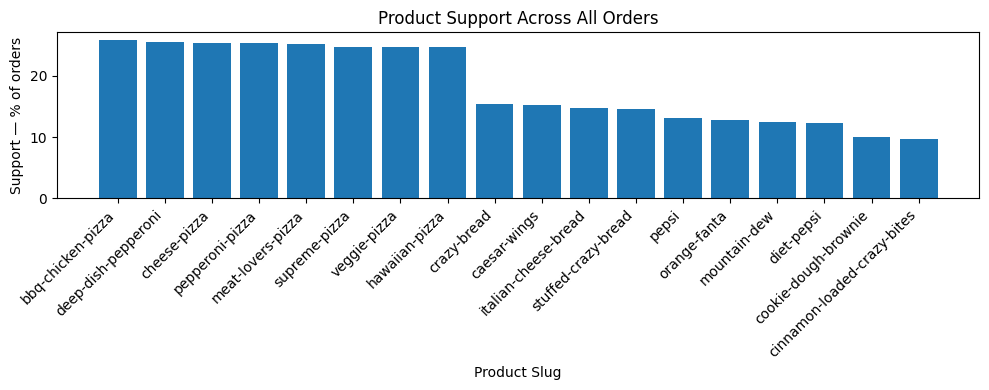

In [6]:
import matplotlib.pyplot as plt

top_items = df_eda.head(18)
plt.figure(figsize=(10, 4))
plt.bar(top_items['order_product'], top_items['support'] * 100)
plt.xlabel('Product Slug')
plt.ylabel('Support — % of orders')
plt.title('Product Support Across All Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 2 — Model Construction (FPGrowth)
A market basket analysis uses the **Apriori** family of algorithms to discover association rules from transactional data. We use PySpark's `FPGrowth` implementation which requires two key thresholds:
* **Support** — minimum proportion of transactions that must contain an itemset for it to be considered frequent.
* **Confidence** — minimum conditional probability that the consequent is purchased given the antecedent is in the cart (ranges 0 → 1).

The model is trained on `train_dataset` and evaluated on the **shared held-out test set** (`test_dataset`) — the same split used by the ALS notebook for a fair comparison.

In [ ]:
from pyspark.ml.fpm import FPGrowth

# With ~12 K training orders, set a reasonable floor
min_transactions = 500
num_of_transactions = train.count()
min_confidence = 0.00   # keep all rules; we filter later by score

fpGrowth = FPGrowth(
    itemsCol='order_product_list',
    minSupport=min_transactions / num_of_transactions,
    minConfidence=min_confidence,
    numPartitions=sc.defaultParallelism * 10
)

# Train on the training set (test set is loaded separately for evaluation)
model = fpGrowth.fit(train)
print(f'{model.associationRules.count()} association rules generated')
display(model.associationRules.sort('antecedent', 'consequent'))

SparkException: [CONNECT_ML.UNSUPPORTED_EXCEPTION] Generic Spark Connect ML error. FPGrowth algorithm is not supported if Spark Connect model cache offloading is enabled. SQLSTATE: XX000

JVM stacktrace:
org.apache.spark.sql.connect.ml.MlUnsupportedException
	at org.apache.spark.sql.connect.ml.MLHandler$.handleMlCommandOss(MLHandler.scala:248)
	at org.apache.spark.sql.connect.ml.MLHandler$._handleMlCommand(MLHandler.scala:562)
	at org.apache.spark.sql.connect.ml.MLHandler$.$anonfun$handleMlCommand$1(MLHandler.scala:615)
	at org.apache.spark.sql.connect.ml.MLHandler$.wrapHandler(MLHandler.scala:591)
	at org.apache.spark.sql.connect.ml.MLHandler$.handleMlCommand(MLHandler.scala:615)
	at org.apache.spark.sql.connect.planner.SparkConnectPlanner.handleMlCommand(SparkConnectPlanner.scala:3566)
	at org.apache.spark.sql.connect.planner.SparkConnectPlanner.process(SparkConnectPlanner.scala:3549)
	at org.apache.spark.sql.connect.execution.ExecuteThreadRunner.handleCommand(ExecuteThreadRunner.sca

In [0]:
model.associationRules.write.format('delta').mode('overwrite') \
    .option('overwriteSchema', 'true') \
    .saveAsTable(rules_table)

print(f'Association rules saved to {rules_table}')

### Evaluate with Hit@k
We measure what proportion of the time the **last item added** to a test cart appears in the top-k recommendations. A higher Hit@k means the model is better at predicting what the customer will add next.

In [0]:
from pyspark.sql.functions import broadcast, array_intersect, array, expr, size, col, power, row_number, collect_list, struct
from pyspark.sql.window import Window

def generate_recommendations(rules_sdf, cart_sdf, k=5, metric='confidence', testing=False):
    """
    Generate top-k product recommendations based on association rules.
    Matches cart items against rule antecedents and scores by a weighted
    combination of the chosen metric and match coverage.
    """
    # Match cart items with rule antecedents
    baskets_and_rules = (
        cart_sdf.join(
            broadcast(rules_sdf.selectExpr('antecedent', 'consequent', 'lift', 'confidence')),
            on=array_intersect(col('cart'), col('antecedent')) != array()
        )
    )

    # Score each rule: weight by how much of the antecedent overlaps the cart
    score = (
        baskets_and_rules
        .filter(expr('not array_contains(cart, consequent)'))
        .withColumn('intr', expr('size(array_intersect(cart, antecedent))'))
        .withColumn('match_score', expr('power(intr, 2) / (size(antecedent) * size(cart))'))
        .withColumn('rule_score', expr(f'{metric} * match_score'))
    )

    return_columns = ['order_id', 'cart']
    if testing:
        return_columns += ['added']

    # Deduplicate per consequent (keep best score), then take top-k
    top_k = (
        score
        .withColumn('rank', row_number().over(Window.partitionBy('order_id', 'consequent').orderBy(col('rule_score').desc())))
        .filter(col('rank') == 1)
        .withColumn('rank', row_number().over(Window.partitionBy('order_id').orderBy(col('rule_score').desc())))
        .filter(col('rank') <= k)
        .groupBy(return_columns)
        .agg(collect_list(struct('consequent', 'rule_score')).alias('recommendations_with_scores'))
    )
    return top_k

In [0]:
from pyspark.sql.functions import expr, size, col, array_contains, slice as spark_slice

# Use the shared test set from 00_data_preparation (same split as ALS notebook)
test_eval = (
    test
    .selectExpr('mpid', 'order_id', 'order_product_list')
).repartition(sc.defaultParallelism * 10)

# Keep only orders with > 1 item, split into cart + last-added item
test_filtered = test_eval.filter(size(col('order_product_list')) > 1)
test_transformed = (
    test_filtered
    .withColumn('cart', expr('slice(order_product_list, 1, size(order_product_list) - 1)'))
    .withColumn('added', expr('order_product_list[size(order_product_list) - 1]'))
)
print(f'{test_filtered.count()} test orders (dropped {test_eval.count() - test_filtered.count()} single-item orders)')

# Load rules
rules = (
    spark.read.table(rules_table)
    .selectExpr('antecedent', 'consequent[0] as consequent', 'lift', 'confidence')
)

# --- Static baseline: top-5 most popular items from training data ---
baseline_recommendations = (
    df_eda.head(5)['order_product'].tolist()
)
print(f'Baseline (top-5 popular): {baseline_recommendations}')

# --- Generate MBA recommendations ---
k = 5
top_k_recommendations = generate_recommendations(rules, test_transformed, k=k, metric='confidence', testing=True)

# --- Compare Hit@k ---
top_k_recommendations = top_k_recommendations.withColumn(
    'hit_at_k_mba',
    expr("cast(array_contains(transform(recommendations_with_scores, x -> x.consequent), added) as int)")
).withColumn(
    'hit_at_k_baseline',
    expr("cast(array_contains(slice(array(" +
         ', '.join([f"'{item}'" for item in baseline_recommendations]) +
         f"), 1, {k}), added) as int)")
)

display(top_k_recommendations.agg({'hit_at_k_mba': 'avg', 'hit_at_k_baseline': 'avg'}))

In [0]:
from pyspark.sql import Row

cart = [Row(order_id='DEMO-001', cart=['pepperoni-pizza', 'crazy-bread'], added='')]
cart_df = spark.createDataFrame(cart)

top_k_recommendations = generate_recommendations(rules, cart_df, k=5, metric='confidence', testing=False)
display(top_k_recommendations)

## 3 — Deployment

Two patterns for serving MBA recommendations. Choose based on rules-table size and retrain cadence:

| | **3a — Packaged Parquet** | **3b — Lakebase-backed** |
|---|---|---|
| **Best for** | Rules fit comfortably in serving-container memory | Rules table too large to package as a model artifact |
| **Freshness** | Static snapshot — must re-log the model after each retrain | Always current — `load_context` reads the latest rules at startup |
| **Inference latency** | Fastest — local parquet read, zero network hops | Slight cold-start overhead from the Lakebase query |
| **Infrastructure** | Self-contained; no external dependency at serving time | Requires a Lakebase online table to be provisioned |
| **Reproducibility** | Rules version is pinned to the MLflow run | Rules may change between model loads; pair with table versioning for auditability |

Both patterns use the **same `predict()` logic**: cross-join the full cart against all rules, score by confidence × match coverage, and return top-k. The only difference is where `load_context` reads the rules from.

---
### 3a — Packaged Parquet (self-contained)
Rules are saved as a parquet file and bundled directly into the MLflow model artifact. At serving time `load_context` reads the local file — zero network dependencies, zero infrastructure beyond the serving endpoint itself.

In [0]:
import pandas as pd
import mlflow.pyfunc
from mlflow.models.signature import ModelSignature
from mlflow.types import ColSpec, Schema, DataType
from mlflow.types.schema import Array

class MBARecommenderModel(mlflow.pyfunc.PythonModel):
    def __init__(self, k=5, metric='confidence'):
        self.k = k
        self.metric = metric

    def load_context(self, context):
        """Load association rules from packaged parquet artifact."""
        rules_path = context.artifacts['rules_file']
        self.rules_df = pd.read_parquet(rules_path)

    def _calculate_match_score(self, row):
        intersection = set(row['cart']).intersection(row['antecedent'])
        return (len(intersection) ** 2) / (len(row['antecedent']) * len(row['cart']))

    def predict(self, context, model_input):
        merged = model_input.merge(self.rules_df, how='cross')
        if merged.empty:
            return []

        # Keep only rules whose antecedent overlaps the cart
        merged = merged[merged.apply(lambda x: bool(set(x['cart']) & set(x['antecedent'])), axis=1)]
        merged['match_score'] = merged.apply(self._calculate_match_score, axis=1)
        merged['rule_score'] = merged[self.metric] * merged['match_score']

        # Remove consequents already in the cart
        merged = merged[~merged.apply(lambda x: x['consequent'] in x['cart'], axis=1)]

        # Best score per (order_id, consequent), then top-k
        grouped = merged.loc[merged.groupby(['order_id', 'consequent'])['rule_score'].idxmax()]
        top_k = (
            grouped.groupby('order_id')
            .apply(lambda x: x.nlargest(self.k, 'rule_score'))
            .reset_index(drop=True)
        )

        result = top_k.groupby('order_id').agg({
            'cart': 'first',
            'consequent': list,
            'rule_score': list
        }).reset_index()
        result.rename(columns={'consequent': 'recommendations'}, inplace=True)
        return result

In [0]:
import mlflow
import os

os.makedirs('artifacts', exist_ok=True)
mlflow.set_experiment(experiment_name)

# Save rules locally as parquet to package as an artifact
rules_pd = (
    spark.read.table(rules_table)
    .selectExpr('antecedent', 'consequent[0] as consequent', 'lift', 'confidence')
).toPandas()
rules_pd.to_parquet('artifacts/rules_table.parquet')

# Define input / output schema
input_schema = Schema([
    ColSpec(DataType.string, 'order_id'),
    ColSpec(Array(DataType.string), 'cart')
])
output_schema = Schema([
    ColSpec(DataType.string, 'order_id'),
    ColSpec(Array(DataType.string), 'cart'),
    ColSpec(Array(DataType.string), 'recommendations'),
    ColSpec(Array(DataType.string), 'rule_score')
])
signature = ModelSignature(inputs=input_schema, outputs=output_schema)

# Sample input for the model
model_input = pd.DataFrame({
    'order_id': ['DEMO-001'],
    'cart': [['pepperoni-pizza', 'crazy-bread']]
})

# Log and register
with mlflow.start_run(run_name='mba_pizza_chain'):
    mlflow.pyfunc.log_model(
        'model',
        python_model=MBARecommenderModel(),
        registered_model_name=model_name,
        artifacts={'rules_file': 'artifacts/rules_table.parquet'},
        input_example=model_input,
        signature=signature
    )
print(f'Model registered as {model_name}')

In [0]:
# Load model from latest run and generate recommendations
details = mlflow.last_active_run()
model_uri = f"runs:/{details.info.run_id}/model"
loaded_model = mlflow.pyfunc.load_model(model_uri)

input_data = pd.DataFrame({
    'order_id': ['DEMO-001', 'DEMO-002'],
    'cart': [
        ['pepperoni-pizza', 'crazy-bread'],
        ['cheese-pizza']
    ]
})

recommendations = loaded_model.predict(input_data)
display(recommendations)

---
### 3b — Lakebase-backed PyFunc
When the rules table is too large to fit in a serving container's memory — or you need rules to stay fresh without re-logging the model — the PyFunc reads from a **Lakebase-backed online table** at `load_context` time.

The production flow:
1. Publish the Delta `association_rules` table to a Lakebase online store (one-time setup)
2. The PyFunc's `load_context` queries the online table via the `databricks-sql-connector` at startup
3. `predict()` cross-joins the full cart against the fetched rules — identical scoring logic to 3a

In [ ]:
import time
from databricks.sdk import WorkspaceClient
from databricks.sdk.errors import BadRequest

w = WorkspaceClient()

# --- Get or create the Lakebase project via REST API ---
# SDK typed classes (Project, ProjectSpec) may not be available in current SDK version
project_name = f'projects/{lakebase_project_id}'
projects_resp = w.api_client.do('GET', '/api/2.0/postgres/projects')
existing_projects = {p['name'] for p in projects_resp.get('projects', [])}

if project_name in existing_projects:
    print(f'Lakebase project already exists: {project_name}')
else:
    print(f'Creating Lakebase project: {project_name} ...')
    try:
        op = w.api_client.do(
            'POST',
            '/api/2.0/postgres/projects',
            query={'project_id': lakebase_project_id},
            body={'spec': {'display_name': 'Pizza Chain Recommender', 'pg_version': 17}},
        )
        while not op.get('done'):
            time.sleep(5)
            op = w.api_client.do('GET', f"/api/2.0/postgres/{op.get('name')}")
        print(f'Lakebase project created: {project_name}')
    except BadRequest as e:
        if 'already exists' in str(e):
            print(f'Lakebase project already exists (caught on create): {project_name}')
        else:
            raise

# --- Create keyed rules table (array columns cannot serve as primary keys) ---
# CDF is required on the source table for TRIGGERED scheduling policy
rules_table_short = rules_table.split('.')[-1]
pk_constraint     = f'{rules_table_short}_pk'

spark.sql(f"""ALTER TABLE {rules_table}
             SET TBLPROPERTIES ('delta.enableChangeDataFeed' = 'true')""")
spark.sql(f"""CREATE OR REPLACE TABLE {rules_table}_keyed AS
              SELECT monotonically_increasing_id() AS rule_id, *
              FROM {rules_table}""")
spark.sql(f"""ALTER TABLE {rules_table}_keyed ALTER COLUMN rule_id SET NOT NULL""")
spark.sql(f"""ALTER TABLE {rules_table}_keyed DROP CONSTRAINT IF EXISTS {pk_constraint}""")
spark.sql(f"""ALTER TABLE {rules_table}_keyed ADD CONSTRAINT {pk_constraint} PRIMARY KEY (rule_id)""")
spark.sql(f"""ALTER TABLE {rules_table}_keyed
             SET TBLPROPERTIES ('delta.enableChangeDataFeed' = 'true')""")
print(f'Created keyed table: {rules_table}_keyed (PK: {pk_constraint})')

# --- Create synced table via REST API ---
# SDK typed classes (SyncedTable) are not yet available in current SDK version
synced_table_id = f'{catalog}.{schema}.association_rules_synced'
branch          = f'{project_name}/branches/production'

op = w.api_client.do(
    'POST',
    '/api/2.0/postgres/synced_tables',
    query={'synced_table_id': synced_table_id},
    body={
        'spec': {
            'source_table_full_name': f'{rules_table}_keyed',
            'project':                project_name,
            'branch':                 branch,
            'primary_key_columns':    ['rule_id'],
            'scheduling_policy':      'TRIGGERED',
            'postgres_database':      postgres_database,
            'create_database_objects_if_missing': True,
        }
    }
)

print(f'Operation started: {op.get("name")}')

for _ in range(60):
    if op.get('done'):
        break
    time.sleep(5)
    op = w.api_client.do('GET', f'/api/2.0/postgres/{op.get("name")}')
    print(f'  {op.get("metadata", {}).get("status", "running")}...')

if op.get('done'):
    print(f'Synced table created: {synced_table_id}')
else:
    print('Operation still running — check the Lakebase UI for status')


In [ ]:
import json
import pandas as pd
import mlflow.pyfunc

class MBALakebaseRecommenderModel(mlflow.pyfunc.PythonModel):
    """
    MBA recommender backed by a Lakebase synced table.

    load_context  — opens a persistent psycopg2 connection (once at container startup)
    predict       — issues a single targeted SQL query per batch using the Postgres
                    array-overlap operator (&&) to fetch only rules relevant to the
                    input carts, then scores and returns top-k in Python
    """
    def __init__(self, k=5, metric='confidence'):
        self.k = k
        self.metric = metric

    def load_context(self, context):
        import psycopg2
        from databricks.sdk import WorkspaceClient

        with open(context.artifacts['config']) as f:
            cfg = json.load(f)

        w = WorkspaceClient()
        credential = w.postgres.generate_database_credential(endpoint=cfg['endpoint'])

        self.conn = psycopg2.connect(
            host=cfg['host'],
            port=5432,
            dbname=cfg['postgres_database'],
            user=cfg['user'],
            password=credential.token,
            sslmode='require',
        )
        self.table = cfg['synced_table']

    def _score(self, antecedent, cart, metric_val):
        overlap = len(set(antecedent) & set(cart))
        match_score = overlap ** 2 / (len(antecedent) * len(cart))
        return metric_val * match_score

    def predict(self, context, model_input):
        # Collect all unique items across every cart — one DB round-trip for the whole batch
        all_items = list({item for cart in model_input['cart'] for item in cart})

        with self.conn.cursor() as cur:
            cur.execute(
                f"""SELECT ARRAY(SELECT jsonb_array_elements_text(antecedent)) AS antecedent,
                           consequent->>0 AS consequent,
                           {self.metric}
                    FROM {self.table}
                    WHERE ARRAY(SELECT jsonb_array_elements_text(antecedent)) && %s::text[]""",
                (all_items,)
            )
            rows = cur.fetchall()

        if not rows:
            return pd.DataFrame(columns=['order_id', 'cart', 'recommendations', 'rule_score'])

        rules_df = pd.DataFrame(rows, columns=['antecedent', 'consequent', self.metric])

        results = []
        for _, row in model_input.iterrows():
            cart     = row['cart']
            order_id = row['order_id']

            relevant = rules_df[
                rules_df['antecedent'].apply(lambda a: bool(set(a) & set(cart)))
            ].copy()

            if relevant.empty:
                continue

            relevant['rule_score'] = relevant.apply(
                lambda r: self._score(r['antecedent'], cart, r[self.metric]), axis=1
            )
            relevant = relevant[~relevant['consequent'].isin(cart)]

            top_k = (
                relevant.loc[relevant.groupby('consequent')['rule_score'].idxmax()]
                .nlargest(self.k, 'rule_score')
            )

            results.append({
                'order_id':        order_id,
                'cart':            cart,
                'recommendations': top_k['consequent'].tolist(),
                'rule_score':      top_k['rule_score'].tolist(),
            })

        return pd.DataFrame(results)


In [ ]:
import os

os.makedirs('artifacts', exist_ok=True)

# Look up the production branch and primary endpoint created with the project
branches          = list(w.postgres.list_branches(parent=f'projects/{lakebase_project_id}'))
production_branch = next(b for b in branches if 'production' in b.name)
endpoints         = list(w.postgres.list_endpoints(parent=production_branch.name))
primary_endpoint  = endpoints[0]

# Inspect available fields to find the correct host attribute
print('Endpoint name  :', primary_endpoint.name)
print('Endpoint spec  :', primary_endpoint.spec)
print('Endpoint status:', primary_endpoint.status)
print('Status attrs   :', [a for a in dir(primary_endpoint.status) if not a.startswith('_')])

In [ ]:
import json, os, psycopg2

os.makedirs('artifacts', exist_ok=True)

# Discover the actual Postgres schema.table for the synced table
credential = w.postgres.generate_database_credential(endpoint=primary_endpoint.name)
_conn = psycopg2.connect(
    host=primary_endpoint.status.hosts.host, port=5432,
    dbname=postgres_database,
    user=w.current_user.me().user_name,
    password=credential.token,
    sslmode='require',
)
with _conn.cursor() as _cur:
    _cur.execute("""
        SELECT table_schema, table_name
        FROM information_schema.tables
        WHERE table_name = 'association_rules_synced'
        LIMIT 1
    """)
    _row = _cur.fetchone()
_conn.close()

if not _row:
    raise RuntimeError('association_rules_synced not found in Postgres — has cell 19 completed?')
synced_table_pg = f'{_row[0]}.{_row[1]}'
print(f'Synced table in Postgres: {synced_table_pg}')

# Write the model class to a standalone .py file for MLflow code-based logging.
# This avoids cloudpickle serialization issues with notebook-defined classes.
model_file = 'artifacts/lakebase_model.py'
with open(model_file, 'w') as _f:
    _f.write('''
import json
import pandas as pd
import mlflow.pyfunc
import mlflow

class MBALakebaseRecommenderModel(mlflow.pyfunc.PythonModel):
    def __init__(self, k=5, metric="confidence"):
        self.k = k
        self.metric = metric

    def load_context(self, context):
        import psycopg2
        from databricks.sdk import WorkspaceClient
        with open(context.artifacts["config"]) as f:
            cfg = json.load(f)
        w = WorkspaceClient()
        credential = w.postgres.generate_database_credential(endpoint=cfg["endpoint"])
        self.conn = psycopg2.connect(
            host=cfg["host"],
            port=5432,
            dbname=cfg["postgres_database"],
            user=cfg["user"],
            password=credential.token,
            sslmode="require",
        )
        self.table = cfg["synced_table"]

    def _score(self, antecedent, cart, metric_val):
        overlap = len(set(antecedent) & set(cart))
        match_score = overlap ** 2 / (len(antecedent) * len(cart))
        return metric_val * match_score

    def predict(self, context, model_input):
        all_items = list({item for cart in model_input["cart"] for item in cart})
        with self.conn.cursor() as cur:
            cur.execute(
                f"""SELECT ARRAY(SELECT jsonb_array_elements_text(antecedent)) AS antecedent,
                           consequent->>0 AS consequent,
                           {self.metric}
                    FROM {self.table}
                    WHERE ARRAY(SELECT jsonb_array_elements_text(antecedent)) && %s::text[]""",
                (all_items,)
            )
            rows = cur.fetchall()
        if not rows:
            return pd.DataFrame(columns=["order_id", "cart", "recommendations", "rule_score"])
        rules_df = pd.DataFrame(rows, columns=["antecedent", "consequent", self.metric])
        results = []
        for _, row in model_input.iterrows():
            cart     = row["cart"]
            order_id = row["order_id"]
            relevant = rules_df[
                rules_df["antecedent"].apply(lambda a: bool(set(a) & set(cart)))
            ].copy()
            if relevant.empty:
                continue
            relevant["rule_score"] = relevant.apply(
                lambda r: self._score(r["antecedent"], cart, r[self.metric]), axis=1
            )
            relevant = relevant[~relevant["consequent"].isin(cart)]
            top_k = (
                relevant.loc[relevant.groupby("consequent")["rule_score"].idxmax()]
                .nlargest(self.k, "rule_score")
            )
            results.append({
                "order_id":        order_id,
                "cart":            cart,
                "recommendations": top_k["consequent"].tolist(),
                "rule_score":      top_k["rule_score"].tolist(),
            })
        return pd.DataFrame(results)

mlflow.models.set_model(MBALakebaseRecommenderModel())
''')
print(f'Model file written: {model_file}')

# Config artifact — synced_table resolved dynamically from Postgres
config = {
    'endpoint':          primary_endpoint.name,
    'host':              primary_endpoint.status.hosts.host,
    'user':              w.current_user.me().user_name,
    'postgres_database': postgres_database,
    'synced_table':      synced_table_pg,
}
with open('artifacts/lakebase_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('Config written:', config)

mlflow.set_experiment(experiment_name)
with mlflow.start_run(run_name='mba_lakebase'):
    mlflow.pyfunc.log_model(
        name='model',
        python_model=model_file,
        registered_model_name=model_name_lakebase,
        artifacts={'config': 'artifacts/lakebase_config.json'},
        pip_requirements=['psycopg2-binary', 'databricks-sdk'],
        signature=signature,
    )
print(f'Model registered as {model_name_lakebase}')


In [ ]:
# Load the Lakebase-backed model and verify it queries Lakebase correctly.
# load_context opens the psycopg2 connection; predict fires a live SQL query.
details      = mlflow.last_active_run()
model_uri    = f"runs:/{details.info.run_id}/model"
loaded_model = mlflow.pyfunc.load_model(model_uri)

input_data = pd.DataFrame({
    'order_id': ['DEMO-001', 'DEMO-002'],
    'cart': [
        ['pepperoni-pizza', 'crazy-bread'],
        ['cheese-pizza']
    ]
})

recommendations = loaded_model.predict(input_data)
display(recommendations)
